## 환경 설정 

In [6]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from transformers import (InstructBlipForConditionalGeneration,
                          T5ForConditionalGeneration,
                          InstructBlipConfig,
                          InstructBlipProcessor, 
                          InstructBlipVisionConfig, 
                          InstructBlipQFormerConfig, 
                          T5Config,
                          T5Tokenizer,
                          AddedToken)
from datasets import load_dataset
from peft import LoraConfig, get_peft_model

from customdatasets import AokvqaDataset, DaconDataset, collate_fn

In [2]:
# 환경 설정
warnings.filterwarnings("ignore")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


## 시드고정

In [3]:
# 시드 고정
def seed_everything(seed=47):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

## instructBLIP 모델 구조 커스텀

In [4]:
# --------------------- 모델 선언부 -----------------------
# 기존 모델 config 로드
vision_config = InstructBlipVisionConfig.from_pretrained("Salesforce/instructblip-flan-t5-xl")
qformer_config = InstructBlipQFormerConfig.from_pretrained("Salesforce/instructblip-flan-t5-xl")
text_config = T5Config.from_pretrained("google/flan-t5-large")

# T5 config 조정 (InstructBLIP에 맞게)
text_config.is_encoder_decoder = True
text_config.use_cache = True
if not hasattr(text_config, 'bos_token_id') or text_config.bos_token_id is None:
    text_config.bos_token_id = 1

# config로 InstructBLIP 모델 생성
config = InstructBlipConfig.from_vision_qformer_text_configs(
    vision_config, qformer_config, text_config
)

# 빈 모델 초기화
model = InstructBlipForConditionalGeneration(config)

print("Model architecture initialized.")

# 사전 훈련된 컴포넌트들 로드
print("Loading pretrained checkpoints...")
# 원본 InstructBLIP 모델 로드 (vision과 qformer 가중치 추출용)
original_model = InstructBlipForConditionalGeneration.from_pretrained("Salesforce/instructblip-flan-t5-xl")

# Vision model 가중치 계승
model.vision_model.load_state_dict(original_model.vision_model.state_dict())
print("✓ Vision model checkpoint loaded")

# Q-Former 가중치 계승
model.qformer.load_state_dict(original_model.qformer.state_dict())
print("✓ Q-Former checkpoint loaded")

# LM (flan-t5-large) 가중치 계승 
new_lm = T5ForConditionalGeneration.from_pretrained("google/flan-t5-large")
model.language_model.load_state_dict(new_lm.state_dict())
print("✓ Language model (flan-t5-large) checkpoint loaded")

# 메모리 정리
del original_model, new_lm
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# projection layer를 Xavier uniform 초기화
nn.init.xavier_uniform_(model.language_projection.weight)
print(f"✓ Language projection layer 재초기화 완료")

# 모델 정보
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n모델 정보:")
print(f"총 파라미터 수: {total_params:,}")

Model architecture initialized.
Loading pretrained checkpoints...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  5.70it/s]


✓ Vision model checkpoint loaded
✓ Q-Former checkpoint loaded
✓ Language model (flan-t5-large) checkpoint loaded
✓ Language projection layer 재초기화 완료

모델 정보:
총 파라미터 수: 1,955,574,528


## 토크나이저 계승

In [17]:
# --------------------- processor, tokenizer 편집부 -----------------------
# # 원래 토크나이저에서 vocab 추출
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-flan-t5-xl")
tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-large")

# <image> 토큰 확인
def check(tokenizer):
    image_token_id = None
    # 토크나이저에 <image> 토큰이 이미 있는지 확인
    if "<image>" in tokenizer.get_vocab():
        image_token_id = tokenizer.convert_tokens_to_ids("<image>")
        print(f"'<image>' 토큰이 토크나이저 어휘에 이미 존재합니다. 인덱스: {image_token_id}")
        # 해당 토큰이 special token인지 확인
        if image_token_id in tokenizer.all_special_tokens:
            print(f"'{image_token_id}' 토큰은 스페셜 토큰입니다.")
        else:
            print(f"'{image_token_id}' 토큰은 일반 토큰입니다 (하지만 모델 내부적으로는 특별하게 처리됨).")
    else: print("!! <image> 토큰이 없음!!")
    return image_token_id

print('large의 경우: \n',check(tokenizer))
print('기존 xl의 경우: \n',check(processor.tokenizer))

xl_tokens = set(processor.tokenizer.get_vocab().keys())     # 기존. xl 모델의 토큰들
large_tokens = set(tokenizer.get_vocab().keys())     # large 모델의 토큰들

image_token = AddedToken("<image>", normalized=False, special=True)
tokenizer.add_tokens([image_token], special_tokens=True)
print(f"Added {image_token} to T5-Large tokenizer.")

tokens_to_add = list(xl_tokens - large_tokens)      # 추가 계승할 토큰
print("More tokens to success: ",tokens_to_add)

num_added = tokenizer.add_tokens(tokens_to_add)   # flan‑t5‑large 토크나이저에 추가
print(f"Added {num_added} tokens from flan-t5-xl into flan-t5-large tokenizer")

processor.tokenizer = tokenizer     # 토크나이저 계승

model.language_model.resize_token_embeddings(len(processor.tokenizer), pad_to_multiple_of=64)    # LM head(임베딩) 크기 리사이즈
print(f"Language model embedding size resized to {len(processor.tokenizer)}.")

image_token_id = processor.tokenizer.convert_tokens_to_ids("<image>")   # 토크나이저의 <image> 토큰 인덱스
model.config.text_config.image_token_index = image_token_id
model.config.image_token_index = image_token_id
print(model.config.image_token_index, model.config.text_config.image_token_index)       # <image> 토큰 인덱스 위랑 확인, 이 두 숫자 같은지 확인

model.config.text_config.vocab_size = len(processor.tokenizer)      # vocab size 업데이트
model.config.vocab_size = len(processor.tokenizer)

del tokenizer, xl_tokens, large_tokens   # 메모리 정리

!! <image> 토큰이 없음!!
large의 경우: 
 None
'<image>' 토큰이 토크나이저 어휘에 이미 존재합니다. 인덱스: 32100
'32100' 토큰은 일반 토큰입니다 (하지만 모델 내부적으로는 특별하게 처리됨).
기존 xl의 경우: 
 32100
Added <image> to T5-Large tokenizer.
More tokens to success:  ['<image>', '<video>']
Added 1 tokens from flan-t5-xl into flan-t5-large tokenizer
Language model embedding size resized to 32102.
32100 32100


In [18]:
# 베이스 모델 저장. !!반드시 PEFT 적용전에 해야함!!
model.base_model.save_pretrained('../Model/instructblip-base')

## 더미입력으로 확인

In [19]:
# 더미입력으로 확인
try:
    from PIL import Image
    import numpy as np
    import requests
    
    # PIL 이미지로 더미 이미지 생성 (RGB, 224x224)
    # dummy_image_array = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
    # dummy_image = Image.fromarray(dummy_image_array, mode='RGB')
    url = "https://raw.githubusercontent.com/salesforce/LAVIS/main/docs/_static/Confusing-Pictures.jpg"
    dummy_image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    dummy_text = "Describe this image."
    
    print("더미 이미지 생성 완료")
    print(f"이미지 크기: {dummy_image.size}, 모드: {dummy_image.mode}")
    
    # 입력 전처리
    inputs = processor(
        images=dummy_image, 
        text=dummy_text, 
        return_tensors="pt"
    )
    
    print("입력 전처리 완료")
    print(f"입력 텐서 키: {list(inputs.keys())}")
    print(f"이미지 텐서 shape: {inputs['pixel_values'].shape}")
    print(f"텍스트 토큰 shape: {inputs['input_ids'].shape}")
    
    # T5 모델을 위한 decoder_input_ids 생성
    # T5는 decoder 시작 시 pad_token_id를 사용
    batch_size = inputs['input_ids'].shape[0]
    decoder_input_ids = torch.full(
        (batch_size, 1), 
        processor.tokenizer.pad_token_id, 
        dtype=torch.long
    )
    inputs['decoder_input_ids'] = decoder_input_ids
    
    print(f"decoder_input_ids 추가: {decoder_input_ids.shape}")
    
    # Forward pass 테스트 (training mode)
    model.train()  # training mode로 설정
    with torch.no_grad():
        outputs = model(**inputs)
    
    print("✓ Forward pass 성공")
    print(f"출력 logits shape: {outputs.logits.shape}")
    print(f"출력 logits 범위: [{outputs.logits.min().item():.4f}, {outputs.logits.max().item():.4f}]")
    
    # Generation 테스트도 수행
    print("\nGeneration 테스트...")
    model.eval()  # evaluation mode로 설정
    with torch.no_grad():
        # decoder_input_ids 제거 (generate에서는 자동 생성)
        gen_inputs = {k: v for k, v in inputs.items() if k != 'decoder_input_ids'}
        generated_ids = model.generate(
            **gen_inputs,
            max_new_tokens=30,
            do_sample=True,
            num_beams=3,
            repetition_penalty=1.5,
        )
    
    # 생성된 텍스트 디코딩
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(f"✓ Generation 성공")
    print(f"생성된 텍스트 (샘플): '{generated_text}...'")
      
    
except Exception as e:
    print(f"✗ 테스트 실패: {str(e)}")
    # 에러 발생 시 더 자세한 디버깅 정보 제공
    import traceback
    print("상세 에러 정보:")
    traceback.print_exc()


print("\n모델 개조 및 테스트 완료!")

더미 이미지 생성 완료
이미지 크기: (570, 380), 모드: RGB
입력 전처리 완료
입력 텐서 키: ['input_ids', 'attention_mask', 'qformer_input_ids', 'qformer_attention_mask', 'pixel_values']
이미지 텐서 shape: torch.Size([1, 3, 224, 224])
텍스트 토큰 shape: torch.Size([1, 38])
decoder_input_ids 추가: torch.Size([1, 1])


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


✓ Forward pass 성공
출력 logits shape: torch.Size([1, 1, 32128])
출력 logits 범위: [-43.3074, 0.0511]

Generation 테스트...
✓ Generation 성공
생성된 텍스트 (샘플): 'a person is having a conversation with someone....'

모델 개조 및 테스트 완료!


# ★★ Finetuning ★★  

## PEFT-LoRA 설정

In [20]:
target_modules = [
    # Q-Former 내의 선형 레이어 (BERT-like 구조)
    "query",            # Q-Former 어텐션의 쿼리 프로젝션
    "key",              # Q-Former 어텐션의 키 프로젝션
    "value",            # Q-Former 어텐션의 값 프로젝션
    "attention.output.dense", # Q-Former 어텐션의 출력 밀집 레이어
    "intermediate.dense", # Q-Former FFN의 중간 밀집 레이어
    "output.dense",       # Q-Former FFN의 출력 밀집 레이어

    # Language Model (Flan-T5-large) 내의 선형 레이어
    "q",                # T5 어텐션의 쿼리 프로젝션
    "k",                # T5 어텐션의 키 프로젝션
    "v",                # T5 어텐션의 값 프로젝션
    "o",                # T5 어텐션의 출력 프로젝션
    "wi_0",             # T5 FFN의 중간 레이어 1
    "wi_1",             # T5 FFN의 중간 레이어 2 (Gated FFN의 경우)
    "wo",               # T5 FFN의 출력 레이어

    # InstructBLIP 특정 레이어
    "language_projection", # 당신이 정의한 Q-Former -> LLM 연결 projection 레이어
    "lm_head"             # 언어 모델의 최종 출력 헤드
]

In [21]:
# 중복 제거
target_module_names = list(set(target_modules))

lora_config = LoraConfig(
    r=16, 
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=target_module_names        
)
model = get_peft_model(model, lora_config)
print(model.print_trainable_parameters())

trainable params: 22,210,560 || all params: 1,977,785,088 || trainable%: 1.1230
None


In [22]:
# A-OKVQA 데이터셋
train_ds = load_dataset("HuggingFaceM4/A-OKVQA", split="train[:50]")
val_ds = load_dataset("HuggingFaceM4/A-OKVQA", split="validation[:10]")

a = len(train_ds)
# 데이터 유효성 확인
train_ds = train_ds.filter(lambda example: len(example['choices']) == 4)
train_ds = train_ds.filter(lambda example: example['correct_choice_idx'] in [0,1,2,3])
print(f"필터링된 샘플 갯수: {len(train_ds) - a}")

Filter: 100%|██████████| 50/50 [00:00<00:00, 886.78 examples/s]

필터링된 샘플 갯수: 0


In [23]:
# A-OKVQA 데이터셋
class AokvqaDataset(torch.utils.data.Dataset):
    """A-OKVQA dataset."""

    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # get image + text
        sample = self.dataset[idx]
        answer_idx = sample['correct_choice_idx']
        answer = sample['choices'][answer_idx]
        image = sample['image'].convert('RGB')
        prompt = f"""
        Based on the image, choose the correct option to the following question.

        Question: {sample['question']}

        Options:
        A. {sample['choices'][0]}
        B. {sample['choices'][1]}
        C. {sample['choices'][2]}
        D. {sample['choices'][3]}

        Answer:
        """
        encoding = self.processor(image, prompt, padding="max_length", max_length=512, truncation=True, return_tensors="pt")
        
        # remove batch dimension
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        label_encoding = self.processor.tokenizer(
            f'{chr(65+answer_idx)}. {answer}',
            max_length=128, # 라벨의 최대 길이 (충분히 크게)
            padding="max_length", # 여기서는 max_length 패딩이 적절
            truncation=True,
            return_tensors="pt"
        )
        encoding["labels"] = label_encoding.input_ids.squeeze(0)
        encoding["labels"][encoding["labels"] == self.processor.tokenizer.pad_token_id] = -100
        return encoding
    

def collate_fn(batch):
    # 'pixel_values', 'qformer_input_ids', 'qformer_attention_mask', 'input_ids', 'attention_mask', 'labels'
    # 이 모든 키들이 배치로 쌓여야 합니다.
    processed_batch = {}
    for key in batch[0].keys():
        processed_batch[key] = torch.stack([sample[key] for sample in batch])
        
    return processed_batch
    
    
train_ds = AokvqaDataset(dataset=train_ds, processor=processor)
val_ds = AokvqaDataset(dataset=val_ds, processor=processor)

In [24]:
from torch.utils.data import DataLoader

batch_size = 2
train_dataloader = DataLoader(train_ds, batch_size=batch_size, collate_fn = collate_fn, shuffle=True, pin_memory=True, num_workers=4)
valid_dataloader = DataLoader(val_ds, batch_size=batch_size, collate_fn = collate_fn, pin_memory=True, num_workers=4)

In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9, last_epoch=-1)

In [26]:
model.to(device)

PeftModel(
  (base_model): LoraModel(
    (model): InstructBlipForConditionalGeneration(
      (vision_model): InstructBlipVisionModel(
        (embeddings): InstructBlipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
        )
        (encoder): InstructBlipEncoder(
          (layers): ModuleList(
            (0-38): 39 x InstructBlipEncoderLayer(
              (self_attn): InstructBlipAttention(
                (qkv): Linear(in_features=1408, out_features=4224, bias=True)
                (projection): Linear(in_features=1408, out_features=1408, bias=True)
              )
              (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
              (mlp): InstructBlipMLP(
                (activation_fn): GELUActivation()
                (fc1): Linear(in_features=1408, out_features=6144, bias=True)
                (fc2): Linear(in_features=6144, out_features=1408, bias=True)
              )
              (layer_n

In [27]:
# --- 훈련 루프 ---
num_epochs = 2
patience = 1
min_eval_loss = float("inf")
early_stopping_hook = 0
tracking_information = []
gradient_accumulation_steps = 16 // batch_size

for epoch in range(num_epochs):
    # ========================= Training =========================
    model.train()
    
    step = 1
    epoch_loss = 0
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        pixel_values = batch.pop("pixel_values").to(device)
        input_ids = batch.pop("input_ids").to(device)
        qformer_input_ids = batch.pop('qformer_input_ids').to(device)
        qformer_attention_mask = batch.pop('qformer_attention_mask').to(device)
        labels = batch.pop('labels').to(device)

        outputs = model(
            input_ids=input_ids,
            pixel_values=pixel_values,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            labels=labels
            )
        loss = outputs.loss
        loss /= gradient_accumulation_steps

        # 역전파
        loss.backward()
        
        if step%gradient_accumulation_steps == 0 or step == len(train_dataloader):
            optimizer.step()
            optimizer.zero_grad()
        
        epoch_loss += loss.item() * gradient_accumulation_steps
        step += 1

    # ========================= Validation =========================
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for batch in tqdm(valid_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):

            pixel_values = batch.pop("pixel_values").to(device)
            input_ids = batch.pop("input_ids").to(device)
            qformer_input_ids = batch.pop('qformer_input_ids').to(device)
            qformer_attention_mask = batch.pop('qformer_attention_mask').to(device)
            labels = batch.pop('labels').to(device)
    
            outputs = model(
                input_ids=input_ids,
                pixel_values=pixel_values,
                qformer_input_ids=qformer_input_ids,
                qformer_attention_mask=qformer_attention_mask,
                labels=labels
                )
            loss = outputs.loss
            
            eval_loss += loss.item()

    # --- 에포크 마무리 및 로깅 ---
    avg_train_loss = epoch_loss / len(train_dataloader)
    avg_eval_loss = eval_loss / len(valid_dataloader)
    current_lr = optimizer.param_groups[0]["lr"]

    tracking_information.append((avg_train_loss, avg_eval_loss, current_lr))
    print(f"Epoch: {epoch+1} | Train Loss: {avg_train_loss:.4f} | Eval Loss: {avg_eval_loss:.4f} | LR: {current_lr}")
    
    # 스케줄러 업데이트
    scheduler.step()

    # 조기 종료 및 모델 저장
    # Early stopping은 전체 loss 합이 아닌 평균 loss로 비교하는 것이 더 직관적입니다.
    if avg_eval_loss < min_eval_loss:
        min_eval_loss = avg_eval_loss
        early_stopping_hook = 0
        model.save_pretrained("Model/instructblip-lora")
        processor.save_pretrained("Model/instructblip-processor")
        print(f"Validation loss decreased ({min_eval_loss:.4f}). Saving model...")
    else:
        early_stopping_hook += 1
        if early_stopping_hook >= patience:
            print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
            break

Epoch 1/2 [Training]:   0%|          | 0/25 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENI

Epoch: 1 | Train Loss: 4.2916 | Eval Loss: 4.4831 | LR: 1e-05
Validation loss decreased (4.4831). Saving model...


Epoch 2/2 [Training]:   0%|          | 0/25 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENI

Epoch: 2 | Train Loss: 4.0231 | Eval Loss: 4.4011 | LR: 9e-06
Validation loss decreased (4.4011). Saving model...


## Inference sample

Predicted Answer: D


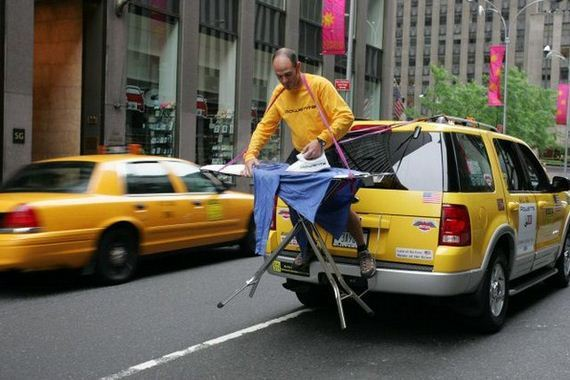

In [29]:
import torch
from PIL import Image
import requests

url = "https://raw.githubusercontent.com/salesforce/LAVIS/main/docs/_static/Confusing-Pictures.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

question = "What is unusual about this image?"
choices = [
    "There is a dog driving a car.",
    "The sky is green and the grass is blue.",
    "The man is ironing his clothes in the road.",
    "There are two moons in the sky."
]

# 🔹 Instruction-style prompt 생성
prompt = (
    "Based on the image, choose the correct option to the following question.\n"
    f"Question: {question}\n"
    "Options:\n" +
    "\n".join([f"{chr(65+i)}. {choice}" for i, choice in enumerate(choices)]) +
    "\nAnswer:"
)

# 🔹 전처리
inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

# 🔹 추론
with torch.no_grad():
    out_ids = model.generate(
        **inputs,
        do_sample=False,       # 샘플링 비활성화 (결정론적 빔 서치)
        num_beams=8,           # 8개의 빔을 사용하여 탐색
        early_stopping=True,   # 빔이 EOS에 도달하면 일찍 중지
        max_new_tokens=50,     # 생성할 최대 새 토큰 수
        min_length=1,
        repetition_penalty=1.2,
        length_penalty=0.8,    # 적절한 길이의 답변 유도
        )

# 🔹 결과 디코딩
answer_text = processor.tokenizer.batch_decode(out_ids, skip_special_tokens=True)[0].strip()
print(f"Predicted Answer: {answer_text}")
Image._show(image)

## Submission

In [ ]:
# 추론
test = pd.read_csv('./test.csv')
results = []

# 정답 알파벳 추출 함수
def extract_answer_letter(text):
    match = re.search(r"\s*([A-Da-d])\.\s*", text)
    return match.group(1).upper() if match else "?"


for _, row in tqdm(test.iterrows(), total=len(test)):
    image = Image.open(row['img_path']).convert("RGB")
    choices = [row[c] for c in ['A', 'B', 'C', 'D']]

    prompt = (
        "Based on the image, choose the correct option to the following question.\n"
        f"Question: {row['Question']}\n"
        "Options:"
        + "\n".join([f"{chr(65+i)}. {choice}" for i, choice in enumerate(choices)]) +
        "\nAnswer:"
    )

    inputs = processor(images=image, text=prompt, padding="max_length", max_length=512, truncation=True, return_tensors="pt").to(device)

    output = model.generate(
        **inputs,
        do_sample=False,       # 샘플링 비활성화 (결정론적 빔 서치)
        num_beams=8,           # 8개의 빔을 사용하여 탐색
        early_stopping=True,   # 빔이 EOS에 도달하면 일찍 중지
        max_new_tokens=50,     # 생성할 최대 새 토큰 수
        min_length=1,
        repetition_penalty=1.2,
        length_penalty=0.8,    # 적절한 길이의 답변 유도
        )
    decoded = processor.tokenizer.decode(output[0], skip_special_tokens=True).strip()
    tqdm.write(f"{decoded}")
    answer = extract_answer_letter(decoded)
    results.append(answer)
    tqdm.write(f"Answer: {answer} \n")

print('✅ Done.')

In [ ]:
submission = pd.read_csv('./sample_submission.csv')
submission['answer'] = results
submission.to_csv('./baseline_submit.csv', index=False)
print("Done.")

## 모델 로드

In [ ]:
# 모델 로드
from transformers import InstructBlipForConditionalGeneration, AutoProcessor
from peft import PeftModel

processor = AutoProcessor.from_pretrained("../Model/instructblip-processor")

model = InstructBlipForConditionalGeneration.from_pretrained('../Model/instructblip-base')

peft_model_path = "../Model/instructblip-lora"
model = PeftModel.from_pretrained(model, peft_model_path)
model.to('cuda')
